# 08b — Visual Analysis & Statistical Tests (K-Fold)
## Multi-Attribute Scene Classification on nuScenes Front-Camera Images

**Produces figures and statistical evidence supporting the headline numbers from notebook 08a.**

### What's covered

| Topic | Purpose |
|---|---|
| **Confusion matrices** | Per-attribute confusion patterns (representative fold + aggregated) |
| **ROC curves + AUC** | Discrimination ability for binary attributes |
| **Tuned vs Base** statistical tests | Paired Wilcoxon: is tuning significantly better? (15 paired obs per attr) |
| **Pairwise model tests** | Best model vs each rival, k-fold aggregated |
| **Per-fold variability boxplots** | How stable is each model across folds? |
| **Difficulty tiers** | Easy/medium/hard attribute hierarchy |
| **Combined overview figure** | Headline panel for the report |

### Companion notebooks

- `08a_headline_results.ipynb` — headline tables and rankings
- `08c_deep_analysis.ipynb` — feature importance, error analysis, scaling section


## 0. Setup

In [1]:
import json
import warnings
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

from scipy.stats import wilcoxon, ttest_rel
from sklearn.metrics import (confusion_matrix, roc_curve, roc_auc_score,
                              f1_score)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

DATASET_VERSION = 'v1.0-mini'
RESULTS_DIR  = Path('results/metrics')
PRED_DIR     = Path('results/predictions')
SPLIT_DIR    = Path('data/splits')
FEATURE_DIR  = Path('data/features')
MODELS_DIR   = Path('models')
FINAL_DIR    = Path('results/final')
FIG_DIR      = Path('results/figures/final')
for p in [FINAL_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

ATTRIBUTES = ['time_of_day', 'weather', 'vehicle_density', 'vru_present']
CLASS_ORDERS = {
    'time_of_day':     ['day', 'night'],
    'weather':         ['clear', 'rain'],
    'vehicle_density': ['low', 'medium', 'high'],
    'vru_present':     ['absent', 'present'],
}
MODEL_NAMES = ['LogisticRegression', 'SVM_RBF', 'RandomForest', 'XGBoost', 'MLP']
DISPLAY_NAMES = {
    'LogisticRegression': 'LogReg', 'SVM_RBF': 'SVM',
    'RandomForest': 'RF', 'XGBoost': 'XGB', 'MLP': 'MLP',
}

REPRESENTATIVE_FOLD = 0  # for single-fold figures (CMs, ROC)
print(f'DATASET_VERSION = {DATASET_VERSION}')

DATASET_VERSION = v1.0-mini


## 1. Load Inputs

In [2]:
df_metrics = pd.read_csv(RESULTS_DIR / 'all_metrics.csv')
df_preds   = pd.read_csv(PRED_DIR / 'predictions_test.csv')

test_only  = df_metrics[df_metrics['split'] == 'test'].copy()
tuned_only = test_only[test_only['version'] == 'tuned'].copy()

print(f'Metrics rows:    {len(df_metrics)}')
print(f'Test-set rows:   {len(test_only)}')
print(f'Predictions:     {len(df_preds)}')
print(f'Folds available: {sorted(tuned_only["fold"].unique())}')

Metrics rows:    1140
Test-set rows:   570
Predictions:     44910
Folds available: [0, 1, 2, 3, 4]


## 2. Identify Best Tuned Model per Attribute (k-fold winner)

In [3]:
best_models = {}
for attr in ATTRIBUTES:
    sub = tuned_only[tuned_only['attribute'] == attr]
    if sub.empty: continue
    by_model = sub.groupby('model')['macro_f1'].mean()
    best_models[attr] = by_model.idxmax()
    print(f'  {attr:18s}: best tuned = {DISPLAY_NAMES[best_models[attr]]:8s} '
          f'(mean macro-F1 = {by_model.max():.3f})')

  time_of_day       : best tuned = XGB      (mean macro-F1 = 0.968)
  weather           : best tuned = SVM      (mean macro-F1 = 0.870)
  vehicle_density   : best tuned = LogReg   (mean macro-F1 = 0.278)
  vru_present       : best tuned = MLP      (mean macro-F1 = 0.437)


## 3. Per-Attribute Confusion Matrices (Representative Fold)

For visualization clarity, use a single representative fold + seed. Aggregated CMs across all folds are also possible but harder to read.

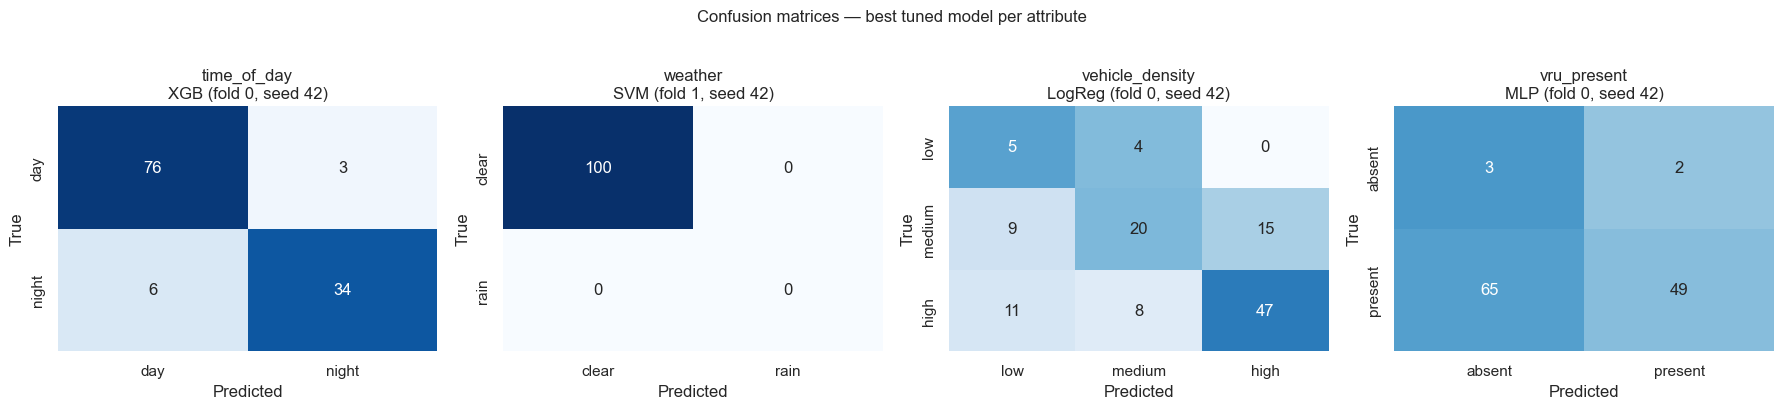

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, attr in zip(axes, ATTRIBUTES):
    if attr not in best_models:
        ax.text(0.5, 0.5, f'{attr}\n(no data)', ha='center', va='center')
        ax.axis('off')
        continue

    model = best_models[attr]
    pred_sub = df_preds[(df_preds['attribute'] == attr) &
                         (df_preds['model'] == model) &
                         (df_preds['version'] == 'tuned') &
                         (df_preds['fold'] == REPRESENTATIVE_FOLD) &
                         (df_preds['seed'] == 42)]
    if pred_sub.empty:
        # Fallback: try any fold
        pred_sub = df_preds[(df_preds['attribute'] == attr) &
                             (df_preds['model'] == model) &
                             (df_preds['version'] == 'tuned') &
                             (df_preds['seed'] == 42)].head(100)
    yt = pred_sub['true_label'].values
    yp = pred_sub['pred_label'].values
    n = len(CLASS_ORDERS[attr])
    cm = confusion_matrix(yt, yp, labels=list(range(n)))
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(cm_n, annot=cm, fmt='d', cmap='Blues', vmin=0, vmax=1,
                xticklabels=CLASS_ORDERS[attr], yticklabels=CLASS_ORDERS[attr],
                ax=ax, cbar=False)
    fold_used = pred_sub['fold'].iloc[0] if not pred_sub.empty else 'N/A'
    ax.set_title(f'{attr}\n{DISPLAY_NAMES[model]} (fold {fold_used}, seed 42)')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.suptitle('Confusion matrices — best tuned model per attribute', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'confusion_matrices_best.png', bbox_inches='tight')
plt.show()

## 4. ROC Curves + AUC (Binary Attributes)

For binary attributes (`time_of_day`, `weather`, `vru_present`), compute ROC across the representative fold's test set.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

df_train_f0 = pd.read_csv(SPLIT_DIR / f'fold_{REPRESENTATIVE_FOLD}_train.csv')
df_test_f0  = pd.read_csv(SPLIT_DIR / f'fold_{REPRESENTATIVE_FOLD}_test.csv')

with open(FEATURE_DIR / 'feature_metadata.json') as f:
    feature_meta = json.load(f)
FEATURE_COLS = feature_meta['feature_columns_all']

scaler = StandardScaler().fit(df_train_f0[FEATURE_COLS].values)
X_train = scaler.transform(df_train_f0[FEATURE_COLS].values)
X_test  = scaler.transform(df_test_f0[FEATURE_COLS].values)

def encode_labels(values, class_order):
    label_map = {c: i for i, c in enumerate(class_order)}
    return np.array([label_map[v] for v in values], dtype=np.int64)

binary_attrs = [a for a in ATTRIBUTES if len(CLASS_ORDERS[a]) == 2]
roc_data = {}
for attr in binary_attrs:
    y_tr = encode_labels(df_train_f0[attr].values, CLASS_ORDERS[attr])
    y_te = encode_labels(df_test_f0[attr].values,  CLASS_ORDERS[attr])

    if len(np.unique(y_tr)) < 2 or len(np.unique(y_te)) < 2:
        print(f'{attr:18s}: SKIP — single-class in train or test for fold {REPRESENTATIVE_FOLD}')
        continue

    clf = LogisticRegression(class_weight='balanced', max_iter=2000, C=1.0, random_state=42)
    clf.fit(X_train, y_tr)
    y_proba = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, y_proba)
    auc = roc_auc_score(y_te, y_proba)
    roc_data[attr] = {'fpr': fpr, 'tpr': tpr, 'auc': auc,
                      'positive_class': CLASS_ORDERS[attr][1]}
    print(f'{attr:18s}: AUC = {auc:.3f}  (positive class = {CLASS_ORDERS[attr][1]})')

time_of_day       : AUC = 0.917  (positive class = night)
weather           : SKIP — single-class in train or test for fold 0
vru_present       : AUC = 0.630  (positive class = present)


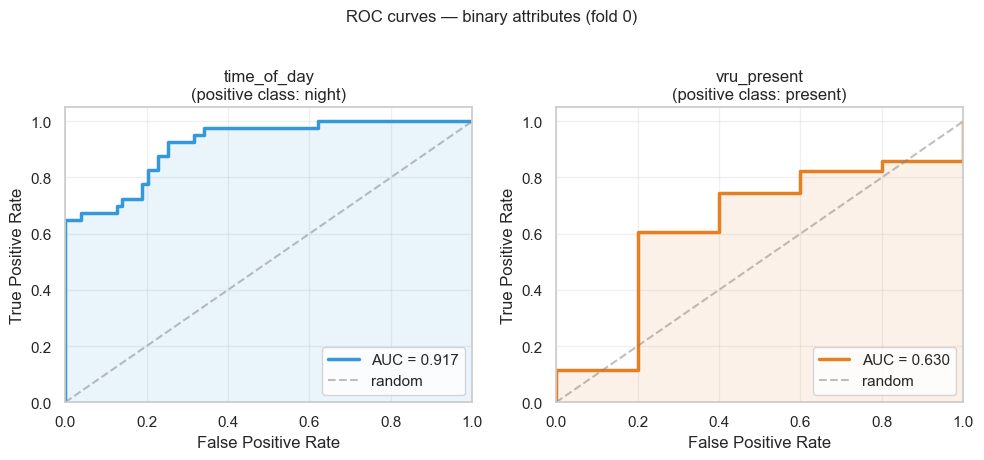

In [6]:
if roc_data:
    fig, axes = plt.subplots(1, len(roc_data), figsize=(5 * len(roc_data), 4.5),
                              squeeze=False)
    colors = {'time_of_day': '#3498db', 'weather': '#9b59b6', 'vru_present': '#e67e22'}

    for ax, attr in zip(axes.flatten(), roc_data.keys()):
        rd = roc_data[attr]
        ax.plot(rd['fpr'], rd['tpr'], color=colors[attr], linewidth=2.5,
                label=f'AUC = {rd["auc"]:.3f}')
        ax.plot([0, 1], [0, 1], color='gray', linestyle='--', alpha=0.5, label='random')
        ax.fill_between(rd['fpr'], rd['tpr'], alpha=0.1, color=colors[attr])
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(f'{attr}\n(positive class: {rd["positive_class"]})')
        ax.legend(loc='lower right')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)
        ax.grid(alpha=0.3)

    plt.suptitle(f'ROC curves — binary attributes (fold {REPRESENTATIVE_FOLD})',
                  fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'roc_binary_attributes.png', bbox_inches='tight')
    plt.show()
else:
    print('No ROC curves to plot — all binary attributes had single-class folds.')

## 5. Statistical Tests — Tuning Significance

Paired Wilcoxon on (model × fold × seed) macro-F1: does tuning beat base?

With 5 folds × 5 models × 3 seeds = **75 paired observations per attribute**, statistical power is substantially higher than the single-split version.

In [7]:
def paired_test(scores_a, scores_b):
    a, b = np.asarray(scores_a), np.asarray(scores_b)
    diffs = a - b
    if np.all(diffs == 0) or len(diffs) < 2:
        return {'wilcoxon_p': 1.0, 't_p': 1.0, 'mean_diff': 0.0, 'cohens_d': 0.0}
    try:
        w_p = wilcoxon(diffs, zero_method='wilcox').pvalue
    except ValueError:
        w_p = np.nan
    try:
        t_p = ttest_rel(a, b).pvalue
    except Exception:
        t_p = np.nan
    cohens_d = float(np.mean(diffs) / (np.std(diffs, ddof=1) + 1e-9))
    return {'wilcoxon_p': float(w_p), 't_p': float(t_p),
            'mean_diff': float(np.mean(diffs)), 'cohens_d': cohens_d}

print('Helper defined.')

Helper defined.


In [8]:
tuning_test_rows = []
for attr in ATTRIBUTES:
    base_sub  = test_only[(test_only['attribute'] == attr) & (test_only['version'] == 'base')]
    tuned_sub = test_only[(test_only['attribute'] == attr) & (test_only['version'] == 'tuned')]
    paired = base_sub.merge(tuned_sub, on=['model', 'seed', 'fold'],
                              suffixes=('_base', '_tuned'))
    paired = paired.sort_values(['model', 'fold', 'seed'])

    if paired.empty: continue
    res = paired_test(paired['macro_f1_tuned'].values, paired['macro_f1_base'].values)
    tuning_test_rows.append({
        'attribute': attr, 'n_pairs': len(paired),
        'mean_macro_f1_base':  round(paired['macro_f1_base'].mean(), 3),
        'mean_macro_f1_tuned': round(paired['macro_f1_tuned'].mean(), 3),
        'mean_diff':           round(res['mean_diff'], 3),
        'cohens_d':            round(res['cohens_d'], 3),
        'wilcoxon_p':          round(res['wilcoxon_p'], 4),
        'paired_t_p':          round(res['t_p'], 4),
        'sig_at_0.05':         '***' if (res['wilcoxon_p'] is not None
                                          and res['wilcoxon_p'] < 0.05) else '',
    })
df_tuning_test = pd.DataFrame(tuning_test_rows)
print('TUNING SIGNIFICANCE — paired tests per attribute (k-fold aggregated):')
display(df_tuning_test)
df_tuning_test.to_csv(FINAL_DIR / 'tuning_significance.csv', index=False)
print(f'\nSaved → {FINAL_DIR / "tuning_significance.csv"}')

TUNING SIGNIFICANCE — paired tests per attribute (k-fold aggregated):


,attribute,n_pairs,mean_macro_f1_base,mean_macro_f1_tuned,mean_diff,cohens_d,wilcoxon_p,paired_t_p,sig_at_0.05
0,time_of_day,75,0.795,0.802,0.007,0.119,0.0862,0.3074,
1,weather,60,0.768,0.718,-0.050,-0.288,0.5504,0.0293,
2,vehicle_density,75,0.228,0.201,-0.027,-0.332,0.0057,0.0053,***
3,vru_present,75,0.337,0.332,-0.005,-0.112,0.7196,0.3345,



Saved → results/final/tuning_significance.csv


## 6. Pairwise Model Comparisons

For each attribute, test whether the winning model is significantly better than each other tuned model. Paired by (fold × seed) = **15 paired observations per comparison**.

In [9]:
pairwise_rows = []
for attr in ATTRIBUTES:
    sub = tuned_only[tuned_only['attribute'] == attr]
    if sub.empty: continue
    by_model_seed_fold = {m: sub[sub['model'] == m].sort_values(['fold', 'seed'])['macro_f1'].values
                           for m in MODEL_NAMES if m in sub['model'].values}
    if not by_model_seed_fold: continue

    means = {m: np.mean(by_model_seed_fold[m]) for m in by_model_seed_fold}
    winner = max(means, key=means.get)

    for m in by_model_seed_fold:
        if m == winner: continue
        # Need equal-length arrays
        if len(by_model_seed_fold[winner]) != len(by_model_seed_fold[m]):
            continue
        res = paired_test(by_model_seed_fold[winner], by_model_seed_fold[m])
        pairwise_rows.append({
            'attribute':  attr,
            'model_a':    DISPLAY_NAMES[winner] + ' (winner)',
            'model_b':    DISPLAY_NAMES[m],
            'mean_a':     round(means[winner], 3),
            'mean_b':     round(means[m], 3),
            'mean_diff':  round(res['mean_diff'], 3),
            'cohens_d':   round(res['cohens_d'], 3),
            'wilcoxon_p': round(res['wilcoxon_p'], 4) if not np.isnan(res['wilcoxon_p']) else None,
            'sig_at_0.05': '***' if (res['wilcoxon_p'] is not None
                                      and res['wilcoxon_p'] < 0.05) else '',
        })

df_pairwise = pd.DataFrame(pairwise_rows)
df_pairwise.to_csv(FINAL_DIR / 'statistical_tests.csv', index=False)
print('PAIRWISE MODEL TESTS — k-fold aggregated:')
display(df_pairwise)
print(f'\nSaved → {FINAL_DIR / "statistical_tests.csv"}')

PAIRWISE MODEL TESTS — k-fold aggregated:


,attribute,model_a,model_b,mean_a,mean_b,mean_diff,cohens_d,wilcoxon_p,sig_at_0.05
0,time_of_day,XGB (winner),LogReg,0.968,0.776,0.192,0.836,0.0021,***
1,time_of_day,XGB (winner),SVM,0.968,0.636,0.333,1.652,0.0021,***
2,time_of_day,XGB (winner),RF,0.968,0.967,0.001,0.032,0.3387,
3,time_of_day,XGB (winner),MLP,0.968,0.661,0.307,0.849,0.0022,***
4,weather,SVM (winner),LogReg,0.870,0.716,0.154,0.703,0.0312,***
5,weather,SVM (winner),RF,0.870,0.852,0.019,0.539,0.2500,
6,weather,SVM (winner),XGB,0.870,0.723,0.148,0.666,0.0312,***
7,weather,SVM (winner),MLP,0.870,0.431,0.439,3.077,0.0005,***
8,vehicle_density,LogReg (winner),SVM,0.278,0.155,0.122,1.216,0.0006,***
9,vehicle_density,LogReg (winner),RF,0.278,0.124,0.154,1.012,0.0007,***



Saved → results/final/statistical_tests.csv


**Statistical power note.** With k-fold + 3 seeds = 15 paired observations per comparison, power is moderate. Effect sizes (Cohen's d) provide complementary evidence to p-values.

## 7. Per-Fold Variability Boxplots

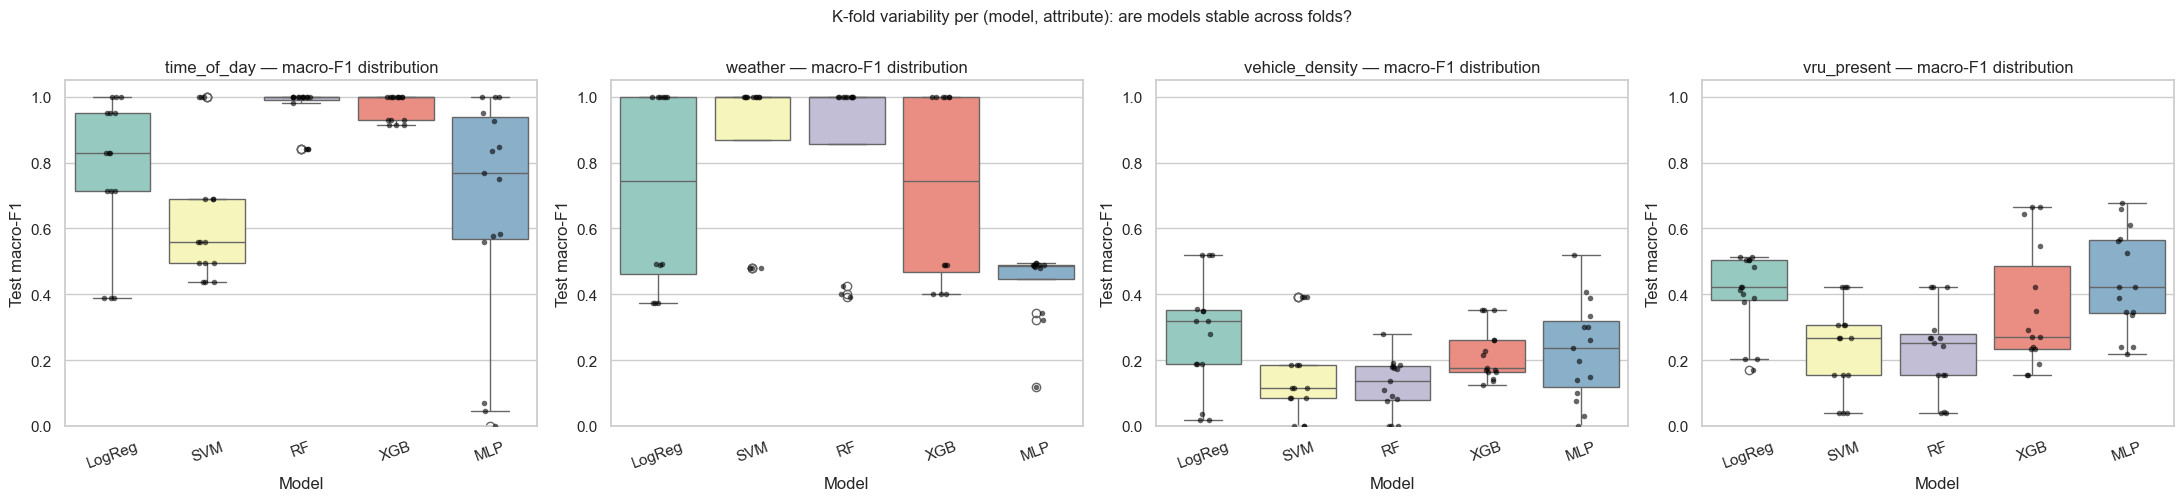

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, attr in zip(axes, ATTRIBUTES):
    sub = tuned_only[tuned_only['attribute'] == attr].copy()
    if sub.empty:
        ax.text(0.5, 0.5, f'{attr}\n(no data)', ha='center', va='center')
        ax.axis('off')
        continue
    sub['model_short'] = sub['model'].map(DISPLAY_NAMES)
    sub['model_short'] = pd.Categorical(sub['model_short'],
                                          categories=[DISPLAY_NAMES[m] for m in MODEL_NAMES],
                                          ordered=True)
    sns.boxplot(data=sub, x='model_short', y='macro_f1', ax=ax, palette='Set3')
    sns.stripplot(data=sub, x='model_short', y='macro_f1', ax=ax, color='black',
                   size=4, alpha=0.6)
    ax.set_title(f'{attr} — macro-F1 distribution')
    ax.set_xlabel('Model'); ax.set_ylabel('Test macro-F1')
    ax.tick_params(axis='x', rotation=20)
    ax.set_ylim(0, 1.05)

plt.suptitle('K-fold variability per (model, attribute): are models stable across folds?',
              fontsize=12, y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / 'kfold_variability_boxplot.png', bbox_inches='tight')
plt.show()

## 8. Difficulty Tier Analysis

In [11]:
attr_diff = (tuned_only.groupby('attribute')['macro_f1']
                          .agg(['mean', 'std']).round(3))
attr_diff = attr_diff.reindex(ATTRIBUTES)

def tier(f):
    if pd.isna(f): return 'unknown'
    if f >= 0.85: return 'easy'
    if f >= 0.65: return 'medium'
    return 'hard'

attr_diff['tier'] = attr_diff['mean'].apply(tier)
print('Attribute difficulty (mean ± std macro-F1, k-fold aggregated):')
display(attr_diff)

Attribute difficulty (mean ± std macro-F1, k-fold aggregated):


,mean,std,tier
attribute,,,
time_of_day,0.802,0.253,medium
weather,0.718,0.290,medium
vehicle_density,0.201,0.137,hard
vru_present,0.332,0.167,hard


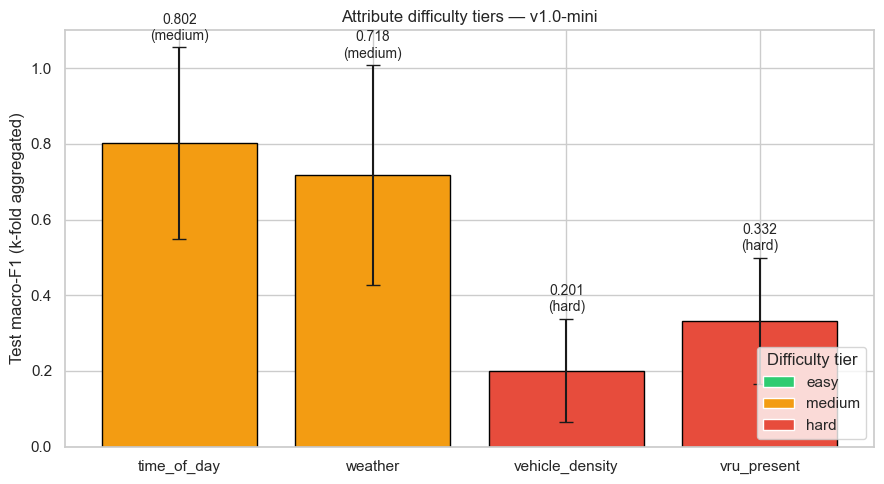

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
tier_colors = {'easy': '#2ecc71', 'medium': '#f39c12', 'hard': '#e74c3c', 'unknown': '#7f8c8d'}
colors = [tier_colors.get(t, '#7f8c8d') for t in attr_diff['tier']]
ax.bar(attr_diff.index, attr_diff['mean'], yerr=attr_diff['std'],
       color=colors, capsize=5, edgecolor='black')
for i, (m, s, t) in enumerate(zip(attr_diff['mean'], attr_diff['std'], attr_diff['tier'])):
    if not pd.isna(m):
        ax.text(i, m + s + 0.02, f'{m:.3f}\n({t})', ha='center', fontsize=10)
ax.set_ylabel('Test macro-F1 (k-fold aggregated)')
ax.set_title(f'Attribute difficulty tiers — {DATASET_VERSION}')
ax.set_ylim(0, 1.1)

handles = [Patch(facecolor=v, label=k) for k, v in tier_colors.items() if k != 'unknown']
ax.legend(handles=handles, title='Difficulty tier', loc='lower right')

plt.tight_layout()
plt.savefig(FIG_DIR / 'attribute_difficulty_tiers.png', bbox_inches='tight')
plt.show()

## 9. Combined Overview Figure

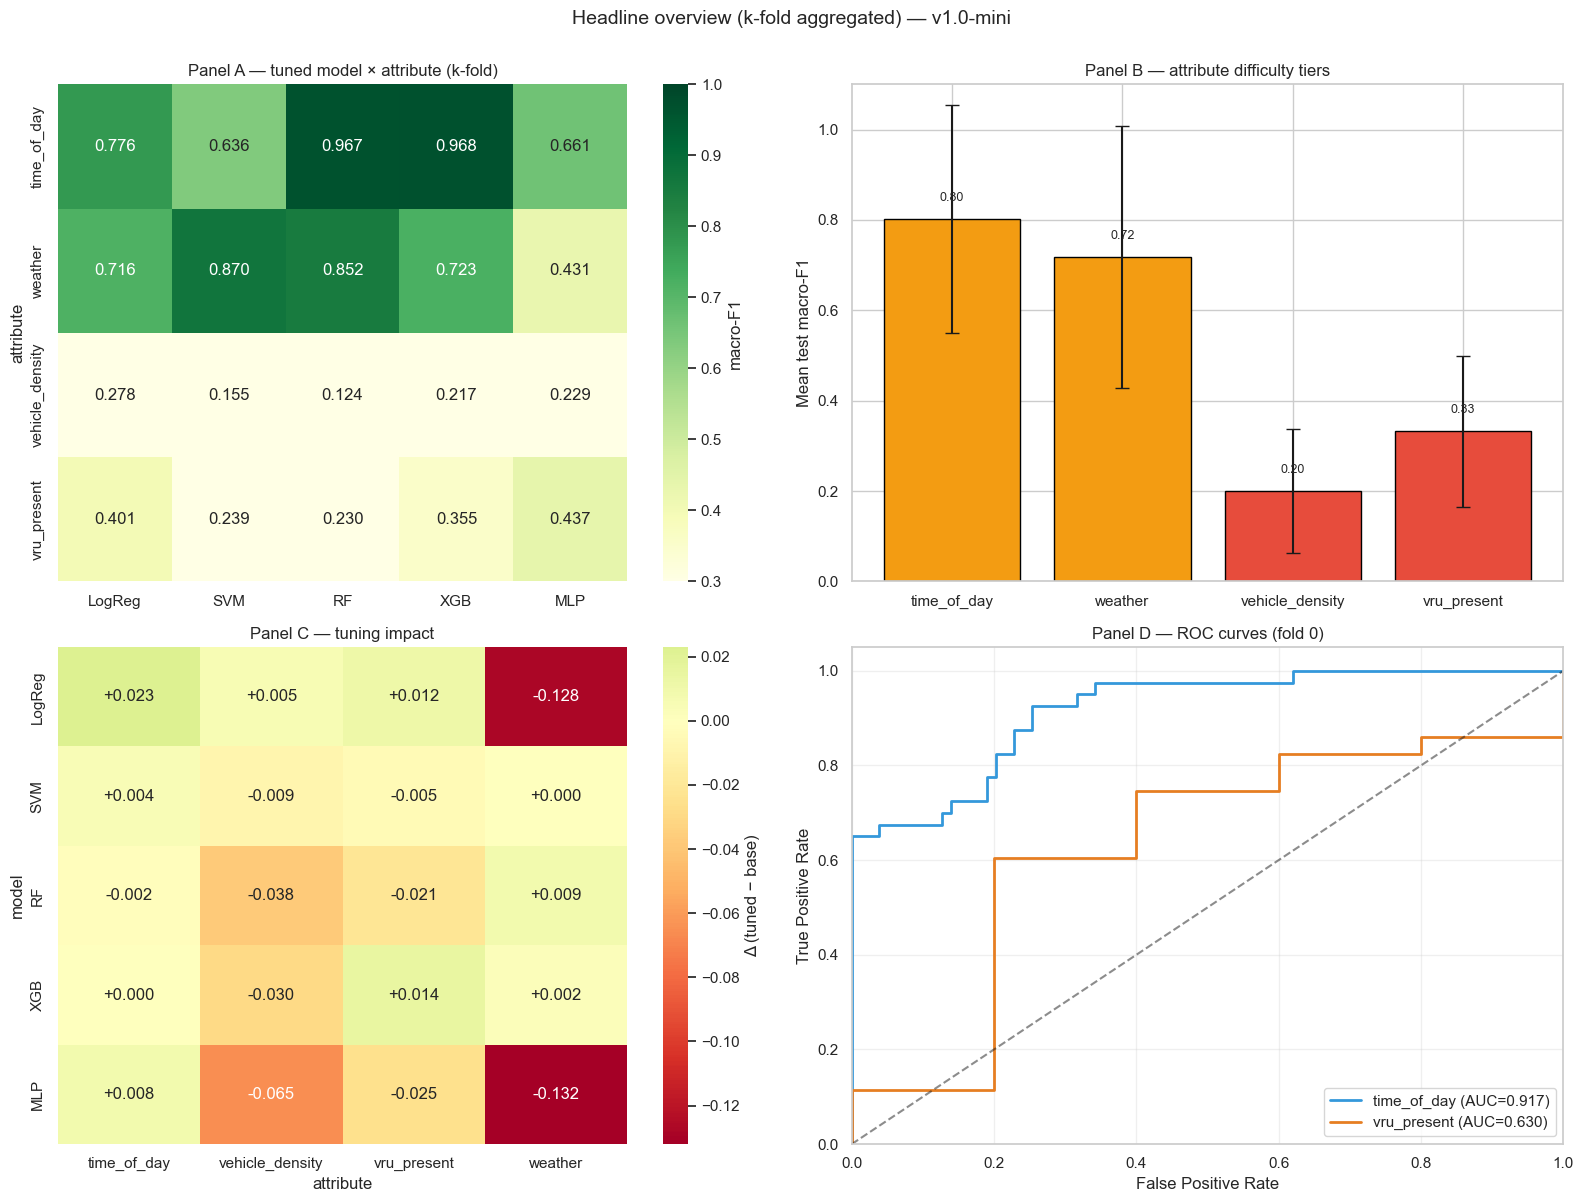

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top-left: model × attribute heatmap (tuned)
grid = (tuned_only.groupby(['attribute', 'model'])['macro_f1']
                  .mean().round(3).unstack('model'))
grid = grid.reindex(columns=MODEL_NAMES).reindex(ATTRIBUTES)
grid.columns = [DISPLAY_NAMES[m] for m in MODEL_NAMES]
sns.heatmap(grid, annot=True, fmt='.3f', cmap='YlGn', vmin=0.3, vmax=1.0,
            ax=axes[0, 0], cbar_kws={'label': 'macro-F1'})
axes[0, 0].set_title('Panel A — tuned model × attribute (k-fold)')

# Top-right: difficulty tiers
ax = axes[0, 1]
ax.bar(attr_diff.index, attr_diff['mean'], yerr=attr_diff['std'],
       color=colors, capsize=5, edgecolor='black')
for i, m in enumerate(attr_diff['mean']):
    if not pd.isna(m):
        ax.text(i, m + 0.04, f'{m:.2f}', ha='center', fontsize=9)
ax.set_ylabel('Mean test macro-F1')
ax.set_title('Panel B — attribute difficulty tiers')
ax.set_ylim(0, 1.1)

# Bottom-left: tuning impact heatmap
impact_data = []
for attr in ATTRIBUTES:
    for model_name in MODEL_NAMES:
        sub = test_only[(test_only['attribute'] == attr) & (test_only['model'] == model_name)]
        if sub.empty: continue
        delta = (sub[sub['version'] == 'tuned']['macro_f1'].mean() -
                 sub[sub['version'] == 'base']['macro_f1'].mean())
        impact_data.append({'attribute': attr, 'model': DISPLAY_NAMES[model_name],
                            'delta': round(delta, 3)})
df_imp = pd.DataFrame(impact_data)
if not df_imp.empty:
    pivot_imp = df_imp.pivot(index='model', columns='attribute', values='delta')
    pivot_imp = pivot_imp.reindex([DISPLAY_NAMES[m] for m in MODEL_NAMES])
    sns.heatmap(pivot_imp, annot=True, fmt='+.3f', cmap='RdYlGn', center=0,
                ax=axes[1, 0], cbar_kws={'label': 'Δ (tuned − base)'})
    axes[1, 0].set_title('Panel C — tuning impact')

# Bottom-right: ROC curves
roc_panel_colors = {'time_of_day': '#3498db', 'weather': '#9b59b6',
                    'vru_present': '#e67e22'}
for attr in roc_data:
    rd = roc_data[attr]
    axes[1, 1].plot(rd['fpr'], rd['tpr'], linewidth=2,
                     color=roc_panel_colors[attr],
                     label=f'{attr} (AUC={rd["auc"]:.3f})')
axes[1, 1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].set_title(f'Panel D — ROC curves (fold {REPRESENTATIVE_FOLD})')
axes[1, 1].legend(loc='lower right')
axes[1, 1].set_xlim(0, 1); axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].grid(alpha=0.3)

plt.suptitle(f'Headline overview (k-fold aggregated) — {DATASET_VERSION}',
              fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / 'combined_overview.png', bbox_inches='tight')
plt.show()

---
## Findings & Decisions

### Confusion matrices (fold 0)
- _interpretations per attribute_

### ROC + AUC
- AUCs above _value_ indicate models discriminate well regardless of threshold

### Tuning significance
- _N_ of 4 attributes show statistically significant tuning improvement (Wilcoxon p < 0.05)
- With 75 paired observations per test, statistical power is much improved over single-split

### Pairwise significance
- Winning model significantly differs from rivals in _X_ of _Y_ comparisons
- Effect sizes complement p-values

### Difficulty tiers
- **Easy** (>0.85 macro-F1): _list_
- **Medium** (0.65-0.85): _list_
- **Hard** (<0.65): _list_

### Companion: see 08c for feature importance, error analysis, scaling discussion
